In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/SUN/PIL-main /content/

In [ ]:
!cp -r "/content/drive/MyDrive//SUN/LEVEL3FITS" /content/

In [ ]:
%cd /content/PIL-main
!pip install astropy scikit-image plotly imageio

/content/PIL-main


In [ ]:
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from skimage.transform import resize

from scripts.imagedata import ImageData
from scripts.neutralliner import NeutralLiner
from scripts.config import FITS_SHAPE

In [ ]:
MODELS_PER_CR = 100
EPOCHS = 4000

device = "cuda" if torch.cuda.is_available() else "cpu"

MCINTOSH_PATH = "/content/LEVEL3FITS"
SAVE_BASE = "/content/drive/MyDrive/macintosh_step_sizes/macintosh_8" #change for different step sizes

os.makedirs(SAVE_BASE, exist_ok=True)

In [ ]:
mc_files = sorted(os.listdir(MCINTOSH_PATH))

# choose first few for now (increase later)
# selected_files = mc_files[:1]
# selected_files = ['ptmc_compo_sm_19550603_092532_cr1361k_l3.fits.gz', 'ptmc_compo_sm_19580209_071219_cr1397k_l3.fits.gz']
selected_files = ['ptmc_compo_sm_19541221_150036_cr1355k_l3.fits.gz','ptmc_compo_sm_19560425_183018_cr1373k_l3.fits.gz', 'ptmc_compo_sm_19570512_142238_cr1387k_l3.fits.gz']
print(selected_files)

['ptmc_compo_sm_19541221_150036_cr1355k_l3.fits.gz', 'ptmc_compo_sm_19560425_183018_cr1373k_l3.fits.gz', 'ptmc_compo_sm_19570512_142238_cr1387k_l3.fits.gz']


In [ ]:
def build_image_data_from_fits(file_path):

    with fits.open(file_path) as hdul:
        img = hdul[0].data[10:-10,10:-10]

    # -------------------------
    # Target (polarity)
    # -------------------------

    target = np.array(img == 7)

    target = resize(
        target.astype(float),
        FITS_SHAPE,
        anti_aliasing=True
    )

    target = target * 2 - 1


    # -------------------------
    # Filaments (FIXED)
    # -------------------------

    filament = np.array(img != 9)

    filament = resize(
        filament.astype(float),
        FITS_SHAPE,
        anti_aliasing=True
    )

    filament = filament > 0.5


    img_data = ImageData(filament, data_mode="img")
    img_data.target_img = target

    # FIX orientation
    h, w = img_data.img_array.shape
    img_data.height = h
    img_data.width = w

    return img_data

In [ ]:
def visualize_sample(file_name):
    file_path = os.path.join(MCINTOSH_PATH, file_name)

    img_data = build_image_data_from_fits(file_path)

    filament = img_data.img_array
    target = img_data.target_img

    plt.figure(figsize=(10, 4))

    # Filament (input)
    plt.subplot(1, 2, 1)
    plt.title("Filament (Input)")
    plt.imshow(filament, cmap='gray')
    plt.colorbar()
    plt.axis('off')

    # Target (polarity)
    plt.subplot(1, 2, 2)
    plt.title("Target (Polarity)")
    plt.imshow(target, cmap='bwr')  # blue-red for -1 to +1
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Showing: ptmc_compo_sm_19541221_150036_cr1355k_l3.fits.gz


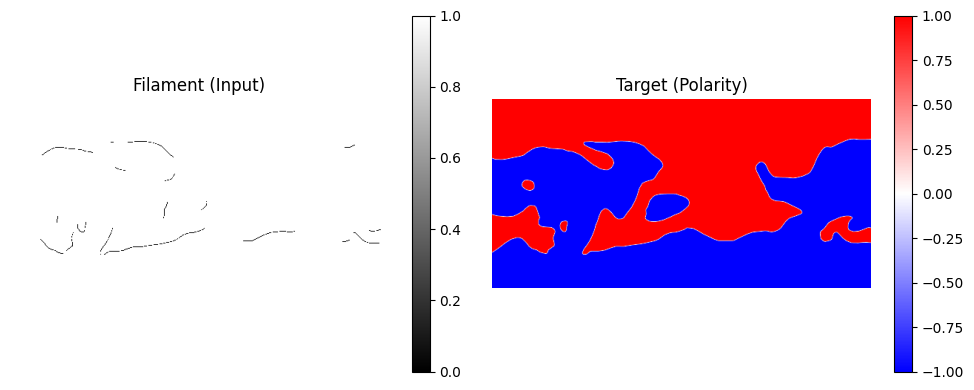

Showing: ptmc_compo_sm_19560425_183018_cr1373k_l3.fits.gz


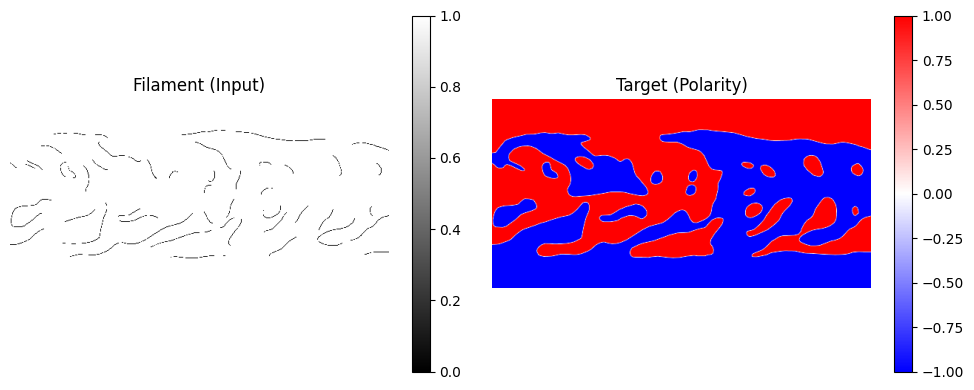

Showing: ptmc_compo_sm_19570512_142238_cr1387k_l3.fits.gz


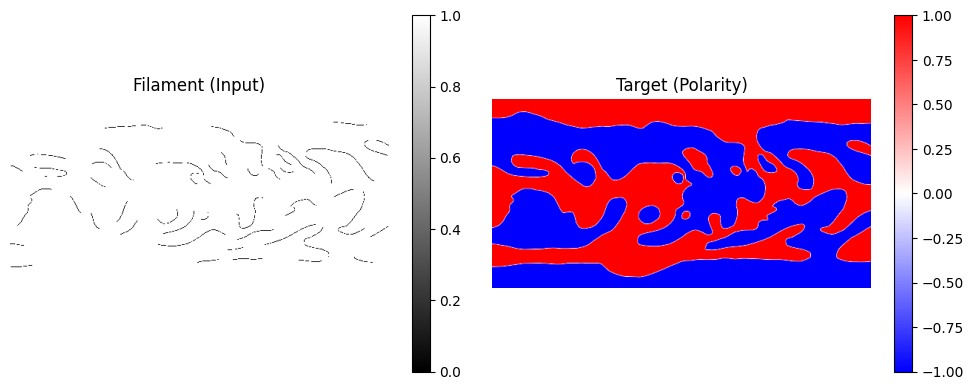

In [ ]:
for file in selected_files:
    print(f"Showing: {file}")
    visualize_sample(file)

In [ ]:
for f in selected_files:

    file_path = os.path.join(MCINTOSH_PATH, f)

    # extract CR number
    match = re.search(r'cr(\d+)', f)
    cr = match.group(1)

    print("\n===========================")
    print(f"Training CR {cr}")
    print("===========================")

    img_data = build_image_data_from_fits(file_path)

    CR_SAVE = f"{SAVE_BASE}/model_CR_{cr}"
    os.makedirs(CR_SAVE, exist_ok=True)


    for k in range(MODELS_PER_CR):

        model_path = f"{CR_SAVE}/model_{k}.pth"

        # resume-safe: skip if already trained
        if os.path.exists(model_path):
            print(f"Skipping model {k}")
            continue

        print(f"Training model {k}")

        model = NeutralLiner(
            image_list=[img_data],
            lr=5e-3,
            help_step_size=8,
            device=device
        )

        model.to(device)

        model.start_training(
            num_epochs=EPOCHS,
            need_plot=False
        )

        torch.save(model.state_dict(), model_path)

        print("Saved:", model_path)


Training CR 1355
Training model 0
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_0.pth
Training model 1
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_1.pth
Training model 2
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_2.pth
Training model 3
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_3.pth
Training model 4
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_4.pth
Training model 5
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_5.pth
Training model 6
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_6.pth
Training model 7
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_7.pth
Training model 8
Saved: /content/drive/MyDrive/macintosh_step_sizes/macintosh_8/model_CR_1355/model_8.pth
Training model 9
Saved: /con

Processing CR 1355...
CR 1355 Error: 0.5271
Processing CR 1373...
CR 1373 Error: 0.5583
Processing CR 1387...
CR 1387 Error: 0.1652


/tmp/ipykernel_1502/3098812302.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


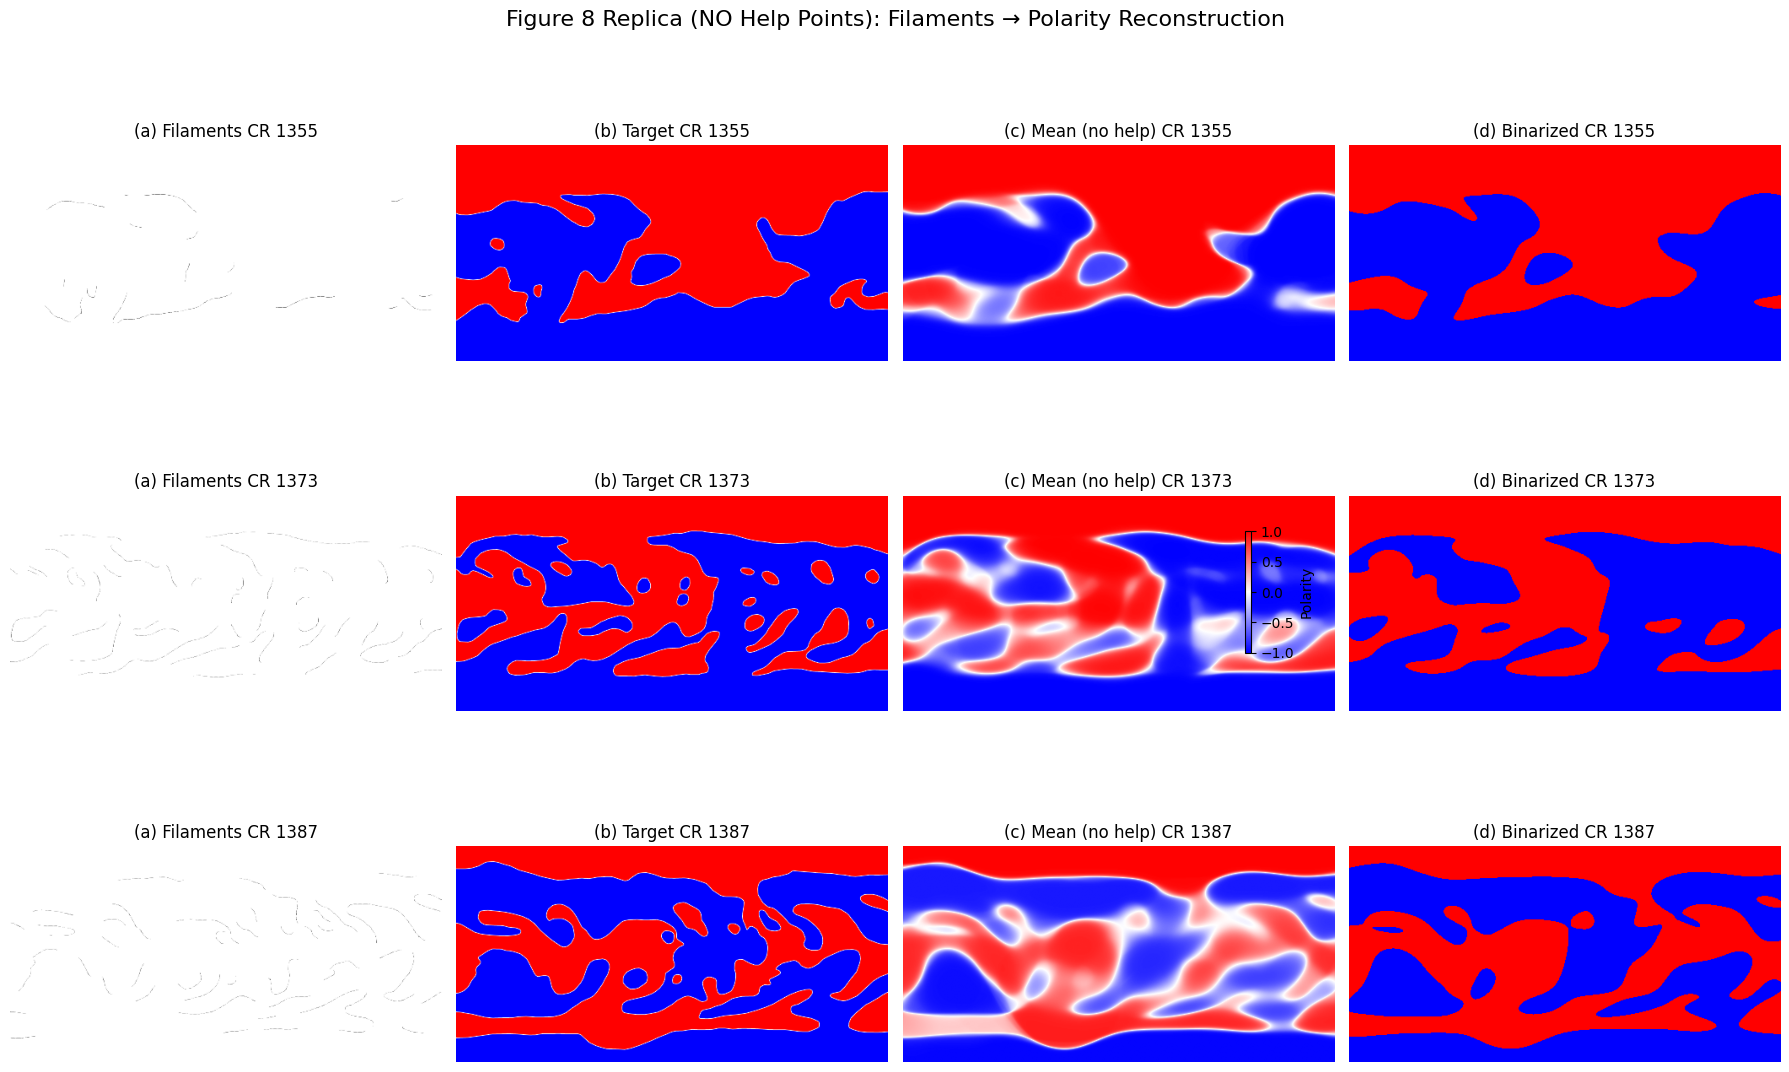

In [ ]:
import matplotlib.pyplot as plt

selected_files = ['ptmc_compo_sm_19541221_150036_cr1355k_l3.fits.gz','ptmc_compo_sm_19560425_183018_cr1373k_l3.fits.gz', 'ptmc_compo_sm_19570512_142238_cr1387k_l3.fits.gz']

fig, axes = plt.subplots(len(selected_files), 4, figsize=(18, 4 * len(selected_files)))

for row, f in enumerate(selected_files):

    # -----------------------------
    # Extract CR + load data
    # -----------------------------
    file_path = os.path.join(MCINTOSH_PATH, f)

    match = re.search(r'cr(\d+)', f)
    cr = match.group(1)

    print(f"Processing CR {cr}...")

    img_data = build_image_data_from_fits(file_path)
    model_dir = f"{SAVE_BASE}/model_CR_{cr}"

    preds = []

    # -----------------------------
    # Load all trained models
    # -----------------------------
    for mf in os.listdir(model_dir):

        if not mf.endswith(".pth"):
            continue

        model = NeutralLiner(
            image_list=[img_data],
            lr=5e-3,
            help_step_size=1,  #change this to 1,8,32, NONE
            device=device
        )

        # fix for no help targets
        if not hasattr(model, "targets"):
            model.targets = [None] * len(model.image_list)

        model.load_state_dict(
            torch.load(os.path.join(model_dir, mf), map_location=device)
        )

        model.to(device)

        with torch.no_grad():
            pred = model(model.data_list[0]).cpu().numpy()

        preds.append(pred)

    # -----------------------------
    # Ensemble
    # -----------------------------
    preds = np.stack(preds)
    pred_mean = np.mean(preds, axis=0)
    pred_map = pred_mean.reshape(img_data.img_array.shape)

    binary_map = np.sign(pred_map)

    # -----------------------------
    # (a) Filament
    # -----------------------------
    axes[row, 0].imshow(img_data.img_array, cmap='gray')
    axes[row, 0].set_title(f"(a) Filaments CR {cr}")
    axes[row, 0].axis('off')

    y, x = np.where(img_data.img_array > 0)
    axes[row, 0].scatter(x, y, s=0.2, c='white', alpha=0.5)

    # -----------------------------
    # (b) Target
    # -----------------------------
    axes[row, 1].imshow(img_data.target_img, cmap='bwr', vmin=-1, vmax=1)
    axes[row, 1].set_title(f"(b) Target CR {cr}")
    axes[row, 1].axis('off')

    # -----------------------------
    # (c) Mean prediction
    # -----------------------------
    im = axes[row, 2].imshow(pred_map, cmap='bwr', vmin=-1, vmax=1)
    axes[row, 2].set_title(f"(c) Mean (no help) CR {cr}")
    axes[row, 2].axis('off')

    # -----------------------------
    # (d) Binarized
    # -----------------------------
    axes[row, 3].imshow(binary_map, cmap='bwr', vmin=-1, vmax=1)
    axes[row, 3].set_title(f"(d) Binarized CR {cr}")
    axes[row, 3].axis('off')

    # -----------------------------
    # Error metric
    # -----------------------------
    error = np.mean(binary_map != img_data.target_img)
    print(f"CR {cr} Error: {error:.4f}")


# -----------------------------
# Shared colorbar
# -----------------------------
cbar = fig.colorbar(
    im,
    ax=axes[:, 2],
    fraction=0.02,
    pad=0.02
)
cbar.set_label("Polarity")


plt.suptitle(
    "Figure 8 Replica (NO Help Points): Filaments → Polarity Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()